# K-Nearest Neighbor Lab
Read over the sklearn info on [nearest neighbor learners](https://scikit-learn.org/stable/modules/neighbors.html#nearest-neighbors-classification)




In [11]:
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
import numpy as np
import pandas as pd
from scipy.io import arff
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

## 1 K-Nearest Neighbor (KNN) algorithm

### 1.1 (15%) Basic KNN Classification

Learn the [Glass data set](https://archive.ics.uci.edu/dataset/42/glass+identification) using [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier) with default parameters.
- Randomly split your data into train/test.  Anytime we don't tell you specifics (such as what percentage is train vs test) choose your own reasonable values
- Give typical train and test set accuracies after running with different random splits
- Print the output probabilities for a test set (predict_proba)
- Try it with different p values (Minkowskian exponent) and discuss any differences

In [12]:
# Learn the glass data
glass_attributes = ["id",
                    "RI",
                    "Na",
                    "Mg",
                    "Al",
                    "Si",
                    "K",
                    "Ca",
                    "Ba",
                    "Fe",
                    "glass_type"
                    ]


# read the csv (using pandas)
glass_df = pd.read_csv("data/glass-identification/glass.data", header=None, names=glass_attributes)


#EDA
print("First 5 rows of glass data set:")
display(glass_df.head())

print("\nGlass Type Distribution:")
display(glass_df["glass_type"].value_counts().sort_index())

print(f"Data shape: {glass_df.shape}")

#split into x and y
X = glass_df.drop(["id", "glass_type"], axis = 1)
y = glass_df["glass_type"]


#knn model generation, training
def knn_split(X, y, test_size = 0.2, p = 2, k = 5, random_state = 0):
    """Split data, initialize and fit KNN using k=5.
    Returns KNN model, splits, and accuracies."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size = test_size, stratify=y, random_state=random_state
    )

    knn_model = KNeighborsClassifier(n_neighbors = k, p = p)
    knn_model.fit(X_train, y_train)
    train_acc = knn_model.score(X_train, y_train)
    test_acc = knn_model.score(X_test, y_test)

    return knn_model, X_train, X_test, y_train, y_test, train_acc, test_acc

#Run with Random States
split = 0.2
p = 2
k = 5
states = np.concatenate([np.array([0]), np.random.randint(0, 101, size=4)])
random_state_models = {}
random_state_results = []

for state in states:
    model, X_train, X_test, y_train, y_test, train_acc, test_acc = knn_split(
        X, y, split, p, k, state
    )
    #save model for each random state tested
    random_state_models[state] = (model, X_train, X_test, y_train, y_test)
    #save accuracies for each model
    random_state_results.append({"state": state, "train_acc": train_acc, "test_acc": test_acc})

random_state_result_df = pd.DataFrame(random_state_results).sort_values(by = "state")
random_state_result_df.set_index("state", inplace = True)
print("\nAccuracies using random states with p = 2:")
display(random_state_result_df)
print("Average train accuracy:", random_state_result_df["train_acc"].mean())
print("Average test accuracy:", random_state_result_df["test_acc"].mean())

#Run with Random Splits
p = 2
k = 5
splits = [0.15, 0.20, 0.30, 0.50, 0.80]
random_split_models = {}
random_split_results = []

for sp in splits:
    model, X_train, X_test, y_train, y_test, train_acc, test_acc = knn_split(
        X, y, sp, p, k
    )
    #save model for each random state tested
    random_split_models[sp] = (model, X_train, X_test, y_train, y_test)
    #save accuracies for each model
    random_split_results.append({"split": sp, "train_acc": train_acc, "test_acc": test_acc})

random_sp_result_df = pd.DataFrame(random_split_results)
random_sp_result_df.set_index("split", inplace = True)
print(f"\nAccuracies using random splits with p = 2 and random state = {states[0]}:")
display(random_sp_result_df)
print("Average train accuracy:", random_sp_result_df["train_acc"].mean())
print("Average test accuracy:", random_sp_result_df["test_acc"].mean())

#Predict Proba using one of the randomly generated states
p2_model, _, X_test, _, y_test = random_state_models[states[0]]
predictions = p2_model.predict(X_test.head())
probabilities = p2_model.predict_proba(X_test.head())

predict_proba_df = pd.DataFrame(
    probabilities, columns=[f"class_{c}" for c in p2_model.classes_]
)
predict_proba_df.insert(0, "predicted_label", predictions)
predict_proba_df.insert(0, "actual_label", y_test.head().values)
print("\nPredicted_proba:")
display(predict_proba_df)


#Try with different p values
split = 0.2
p_values = [1, 2, 3]
p_value_models = {}
p_value_results = []

for p in p_values:
    model, X_train, X_test, y_train, y_test, train_acc, test_acc = knn_split(
        X, y, split, p, k
    )
    #save model for each random state tested
    p_value_models[p] = (model, X_train, X_test, y_train, y_test)
    #save accuracies for each model
    p_value_results.append({"p": p, "train_acc": train_acc, "test_acc": test_acc})


p_value_result_df = pd.DataFrame(p_value_results)
p_value_result_df.set_index("p", inplace = True)
print("\nAccuries using a single 80/20 split per p:")
display(p_value_result_df)

First 5 rows of glass data set:


,id,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,glass_type
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1



Glass Type Distribution:


glass_type
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64

Data shape: (214, 11)

Accuracies using random states with p = 2:


...

,train_acc,test_acc
split,,
0.15,0.779006,0.696970
0.20,0.777778,0.674419
0.30,0.758389,0.676923
0.50,0.654206,0.588785
0.80,0.714286,0.616279


Average train accuracy: 0.7367327772293945
Average test accuracy: 0.6506750990080701

Predicted_proba:


,actual_label,predicted_label,class_1,class_2,class_3,class_5,class_6,class_7
0,3,1,0.6,0.0,0.4,0.0,0.0,0.0
1,1,3,0.4,0.0,0.6,0.0,0.0,0.0
2,2,2,0.2,0.6,0.2,0.0,0.0,0.0
3,2,6,0.0,0.2,0.0,0.2,0.6,0.0
4,3,1,0.8,0.0,0.2,0.0,0.0,0.0



Accuries using a single 80/20 split per p:


,train_acc,test_acc
p,,
1,0.760234,0.697674
2,0.777778,0.674419
3,0.777778,0.604651


#### Discussion
What were your accuracies or output probabilities and how did different hyperparameter values affect the outcome? Discuss the differences you see.

In this first part of the problem, I started with a quick EDA of the data set that we are using, I then wrote a function that can create, fit, and score a KNN model based on a couple hyperparameters (to be changed in a later part of the assignment). I then followed a fairly streamlined process in order to compare the differences in test and train scores for: different random samples of the data, different splits (other than 80/20) of the data, the predicted probabilities of one test set using p = 2, and then different norm values. 

My observations are as follows:

My initial exploratory data analysis didn't conclude much. The data that we were given is nice and uniform, there are no missing values, it seems like an appropriate data set to run a classification model on.

In testing 5 different random samples of the data - which I did by changing the random-seed of the KNeighborsClassifier() - I noticed that in all of the situations I ran, the test and train accuracies of any given random state were relatively close to one another (with few exceptions, like random-seed 94 which has a much higher test accuracy, but an expected/reasonable train accuracy for no apparent reason). Though there isn't a way to conclude this for sure, and the outliers could skew an actual analysis of this, I would be inclined to say that the data set is relatively well balanced if the majority of random samples using the same split, number of neighbors, and distance metric are incredibly similar. The average train and test accuracies for these test seems to commonly have about a .1 gap between them, with the train accuracy being higher than the test accuracy, suggesting that the model could be slightly overfitted to the training portion of the data.

In testing 5 different splits ([0.15, 0.20, 0.30, 0.50, 0.80]), with a set random seed of 0, I was suprised to find that the train and test accuracies were essentially the same for the 0.15, 0.20., 0.30, and 0.80 splits. I was expecting a much different values when such a large proportion of the data is used to test rather than train. Both the test and train accuracies for the 0.5 split are nearly 0.1 lower than the other values. I am not sure why this is. I would be interested to see what using different random states does to this, maybe it has something to do with the data that is being fed into it. The average test and train accuracies for this are comparable to the test that was done imemediately previous to this, suggesting that this model too may be overfitted.

Predicte_proba displays a table of the first five of the predicted classes, the actual classes, and the probabilities it calculated for each of the data points. It works as expected and predicts the class that has the highest probability. I wouldn't say that anything about this is particularly insightful or surprising to me.

Lastly, in testing the different distance metrics, I observed that p = 1 had the lowest test but the highest train accuracy, p = 2 and p = 3 had the same train accuracy, and p = 2 had the highest test accuaracy and almost as high test accuracy as p =1. I am not entirely sure what this tell us, though it could be evidence as to part of the reason why p = 2 is the default, I think it would have the best accuracy and precision on average which is desirable for a classification model. 

## 2 KNN Classification with normalization and distance weighting

Use the [magic telescope](https://axon.cs.byu.edu/data/uci_class/MagicTelescope.arff) dataset

### 2.1 (5%) - Without Normalization or Distance Weighting
- Do random 80/20 train/test splits each time
- Run with k=3 and *without* distance weighting and *without* normalization
- Show train and test set accuracy

In [ ]:
# Learn magic telescope data
# Create Data Frames from the data files
train_data, train_meta = arff.loadarff("data/magic-telescope/magic_telescope_train.arff")
test_data, test_mets = arff.loadarff("data/magic-telescope/magic_telescope_test.arff")

tr_df = pd.DataFrame(train_data)
te_df= pd.DataFrame(test_data)

# Concatonate data sets in order to split into desired 80/20 later
magic_telescope_df = pd.concat([tr_df, te_df], ignore_index = True)

#EDA
print("First 5 rows of magic telescope data set:")
display(magic_telescope_df.head())

print("\nMagic Telescope Class Distribution:")
display(magic_telescope_df["class"].value_counts())

print(f"Data shape: {magic_telescope_df.shape}")

#split into x and y
X = magic_telescope_df.drop(["class"], axis = 1)

encoder = LabelEncoder()
y = encoder.fit_transform(magic_telescope_df["class"])

print("\nRunning KNNeighbors with k = 3, NO weighting, and NO normalization:")

model, X_train, X_test, y_train, y_test, train_acc, test_acc = knn_split(
        X, y, 0.2, 2, 3, random_state=0)

print(f"\n\tAverage train accuracy: {train_acc}")
print(f"\tAverage test accuracy: {test_acc}")

First 5 rows of magic telescope data set:


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,22.7815,14.9526,2.4362,0.4982,0.2509,-14.2836,-9.3635,13.0939,3.0779,141.5620,b'g'
1,40.6756,15.5940,2.7447,0.2772,0.1449,19.6226,9.0297,7.4157,15.4260,193.2340,b'g'
2,12.8427,11.3821,2.1255,0.7191,0.4232,-14.9637,8.5891,6.9418,82.4198,183.9790,b'g'
3,77.0262,32.2880,3.3502,0.3152,0.1868,-28.6712,-35.9464,-31.4001,0.8940,357.0440,b'g'
4,27.5146,11.2114,2.6637,0.4643,0.2687,42.4467,33.0422,-6.3980,50.3004,239.8878,b'h'



Magic Telescope Class Distribution:


class
b'g'    12332
b'h'     6688
Name: count, dtype: int64

Data shape: (19020, 11)

Running KNNeighbors with k = 3, NO weighting, and NO normalization:

	Average train accuracy: 0.8859752891692955
	Average test accuracy: 0.804416403785489


#### Discussion
What did you observe in your results?

In this portion of the assignment I took the two train and test data sets, read the files, converted them into data frames, and concated them together in order to obtain the right 80/20 split (using my function defined in the previous part). I did this because I noted that both test and train had class values, and so there wasn't something that explicitly limited me from just having a larger training set to begin with and then split. I acknoweldge that this probably isn't the "right" practice, but in talking to a TA, it seemed like there wasn't a whole lot that mattered about what data frame was used, and just that I demonstrated understading and proficiency. I made sure to encode the y data because it was not numeric and it was giving me some issues in the process, so I encoded it in order to get 0's and 1's (a metric that SKlearn and the classification model seem to like a whole lot more.)

From there, I just printed the average test and train accuracies, as the point of this part of the assignment was just to get a baseline to see how adding normalization and weighting affects the overall accuracy of a model. The average train accuracy is just below .90, which I would be inclined to say seems pretty good! And the average test accuracy is right about 0.80, so there is definitely room to improve in predicted the test classes. 

*not shown*
I also ran the data using only the training data (rather than the concatonated form that I made) to see if it drastically differed. The average test and train accuracies barely changed, which probably means that the test and train sets provided are fairly good/equal spreads of information since they don't change the accuracy of the model in any significant way. 

### 2.2 (10%) With Normalization
- Try it with k=3 without distance weighting but *with* normalization of input features.  You may use any reasonable normalization approach (e.g. standard min-max normalization between 0-1, z-transform, etc.)

In [14]:
# Train/Predict with normalization
scaler = StandardScaler()

# Normalize
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize, fit, score a new model based on scaled data
knn_model = KNeighborsClassifier(n_neighbors = 3)
knn_model.fit(X_scaled, y_train)

train_acc = knn_model.score(X_scaled, y_train)
test_acc = knn_model.score(X_test_scaled, y_test)

print("\nRunning KNNeighbors with k = 3, NO weighting, and normalization:")
print(f"\n\tAverage train accuracy: {train_acc}")
print(f"\tAverage test accuracy: {test_acc}")


Running KNNeighbors with k = 3, NO weighting, and normalization:

	Average train accuracy: 0.9041798107255521
	Average test accuracy: 0.8351735015772871


#### Discussion
Discuss the results of using normalized data vs. unnormalized data

Here, I followed a similar process except I was sure to use a scaler to scale the x train and test data that I use to fit and calculate the scores.

In general, normalizing the data wil, reduce the bias of a model. This is a good practice for any situation in which some of the numbers are way higher than another. In this case, normalizing/standardizing the data caused both the average train and average test accuracy to increase by about 0.02-0.03, which isn't a huge difference, but it is one! Also, the gab between the two closed slightly, maybe suggesting that normalizing the data helped to reduce some of the overfitting that may exist.

### 2.3 (10%) With Distance Weighting
- Try it with k=3 and with distance weighting *and* normalization

In [15]:
# Initialize, fit, score a new model based on previously scaled data, created in a function to use in the next part

knn_model = KNeighborsClassifier(n_neighbors = 3, weights = "distance")
knn_model.fit(X_scaled, y_train)

train_acc = knn_model.score(X_scaled, y_train)
test_acc = knn_model.score(X_test_scaled, y_test)

print("\nRunning KNNeighbors with k = 3, NO weighting, and normalization:")
print(f"\n\tAverage train accuracy: {train_acc}")
print(f"\tAverage test accuracy: {test_acc}")


Running KNNeighbors with k = 3, NO weighting, and normalization:

	Average train accuracy: 1.0
	Average test accuracy: 0.8372765509989485


#### Discussion
Comparison and discuss the differences you see with distance weighting and normalization vs without.

The same process was followed here yet again, I just added a small 'weights = "distance"' to ensure that the data values were being weighted by their distance.

Now, the average train accuracy is 1.0! Which means the model perfectly predicts the data set that it was trained on. The average test accuracy stayed relatively the same from when it was just based on normalization. But compared to the original test accuracy, it is an improvement. An almost 0.2 gap exists between the average train and average test accuracy, this is probabably a good candidate for overfitting, but it still could be worse! Overall, from the little I know, I would say that this is an improvement overall!

### 2.4 (10%) Different k Values
- Using your normalized data with distance weighting, create one graph with classification accuracy on the test set on the y-axis and k values on the x-axis.
- Use values of k from 1 to 15.  Use the same train/test split for each. 

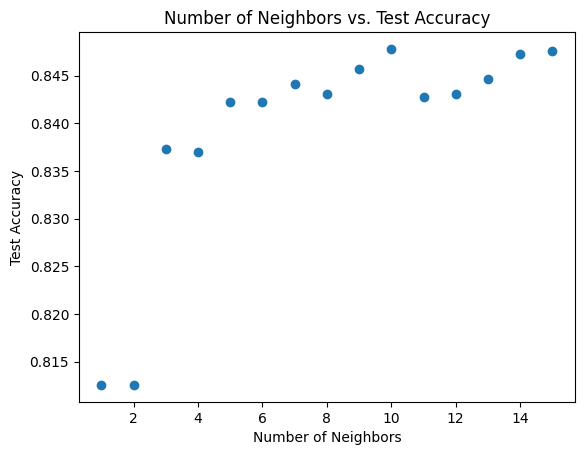

In [16]:
neighbors = [k for k in range(1, 16)]
test_accuracies = []
# Get test accuracies for each of the k values
for k in neighbors:
    knn_model = KNeighborsClassifier(n_neighbors = k, weights = "distance")
    knn_model.fit(X_scaled, y_train)
    test_acc = knn_model.score(X_test_scaled, y_test)
    test_accuracies.append(test_acc)

#print(neighbors)
#print(test_accuracies)

#Plot it!
plt.scatter(neighbors, test_accuracies)
plt.xlabel("Number of Neighbors")
plt.ylabel("Test Accuracy")
plt.title("Number of Neighbors vs. Test Accuracy")

plt.show()

#### Discussion
How do the k values affect your results?

The implementation here is easy - just a simple for loop that iterates through the k number of neigbors from 1 to 15 and then calculates the accuracy of each model based on the number of neighbors so that I could then plot it. 

The *general* trend here is that as the number of neighbors, k, increases, the test accuracy also increases. This is obviously not always perfectly true, but there is a general upward trend that exists here. Having number of neighbors < 3 showing significantly lower accuracy values than for 3+, but even values 3 and 4 stand out as lower than the values of the test accuracy of k = 5+. (Which definitely gives context for a potential reason why the minimum k value that most people use is 5.)

It suprised me to see a peak in the test accuracies around 10 neighbors, a dip back down to a similar accuracy to 8 neighbors, and then a slow rise back up to 15 where the accuracy of k = 15 is not significantly different from the accuracy of k = 10. I was expecting there to be an increase like this across the entire range of k values, so it was interesting to see that this wasn't the case. I am not quite sure why this would be but it is interesting. 

## 3 KNN Regression with normalization and distance weighting

Use the [sklean KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html#sklearn.neighbors.KNeighborsRegressor) on the [housing price prediction](https://axon.cs.byu.edu/data/uci_regression/housing.arff) problem.  
### 3.1 (5%) Ethical Data
Note this data set has an example of an inappropriate input feature which we discussed.  State which feature is inappropriate and discuss why.

#### Discussion
Discuss the innapropriate feature. Which one and why?

I am pretty sure the unethical, innapropriate feature in this data set would be "1000(Bk - 0.63)^2 where Bk is the proportion of blacks % by town."

Though ethnicities and races can have an effect on certain output classes, including it like this, with the specific terminology used, and not including any other races or ethnicities as potential input features seems to suggest that that is the only one that would have any influence or effect on the predicted output feature. Doing it like this almost propogates historical racist beliefs and by continuing to price houses based on something like that continus the racism. The best thing to do here would not be include that at all in the input features because, hopefully, today, that would not be a predictor of housing prices at all. 

### 3.2 (15%) - KNN Regression 
- Do random 80/20 train/test splits each time
- Run with k=3
- Print the score (coefficient of determination) and Mean Absolute Error (MAE) for the train and test set for the cases of
  - No input normalization and no distance weighting
  - Normalization and no distance weighting
  - Normalization and distance weighting
- Normalize inputs features where needed but do not normalize the output

In [10]:
# Learn housing prices data
# Create Data Frames from the data files
train_data, train_meta = arff.loadarff("data/housing-prices/housing_train.arff")

prices_df= pd.DataFrame(train_data)

#EDA
print("First 5 rows of housing prices data set:")
display(prices_df.head())

print("\nGlass Type Distribution:")
display(prices_df["MEDV"].value_counts())

print(f"Data shape: {prices_df.shape}")

#split into x and y
X = prices_df.drop(["MEDV"], axis = 1)
y = prices_df["MEDV"]

#Function for running each split
def knn_regression(X, y, normalization = False, weights="uniform", test_size = 0.2, k = 3, random_state = np.random.randint(0, 1000)):
    """Initialize and fit a KNNeighbors Regression Model that can have normalization and/or
    weighting on hyperparameters.
    Calculates and returns the train and test MAE and coefficient of determination.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size = test_size, random_state = random_state #randomly generated state // in the func so i can set it in the next part
    )

    knn_model = KNeighborsRegressor(n_neighbors = k, weights = weights)

    if normalization:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        knn_model.fit(X_train_scaled, y_train)
        y_train_pred = knn_model.predict(X_train_scaled)
        y_test_pred = knn_model.predict(X_test_scaled)
    else:
        knn_model.fit(X_train, y_train)
        y_train_pred = knn_model.predict(X_train)
        y_test_pred = knn_model.predict(X_test)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    return train_mae, train_r2, test_mae, test_r2

print("\nRunning KNNeighbors Regression with k = 3, NO weighting, and NO normalization:")
train_mae, train_r2, test_mae, test_r2 = knn_regression(X, y)
print(f"\n\tTrain MAE: {train_mae}\n\t Train Coefficient of Determination: {train_r2}")
print(f"\n\tTest MAE: {test_mae}\n\t Test Coef. of Determination: {test_r2}")

print("\nRunning KNNeighbors Regression with k = 3, NO weighting, and normalization:")
train_mae, train_r2, test_mae, test_r2 = knn_regression(X, y, True)
print(f"\n\tTrain MAE: {train_mae}\n\t Train Coefficient of Determination: {train_r2}")
print(f"\n\tTest MAE: {test_mae}\n\t Test Coef. of Determination: {test_r2}")

print("\nRunning KNNeighbors Regression with k = 3, weighting, and normalization:")
train_mae, train_r2, test_mae, test_r2 = knn_regression(X, y, True, "distance")
print(f"\n\tTrain MAE: {train_mae}\n\t Train Coefficient of Determination: {train_r2}")
print(f"\n\tTest MAE: {test_mae}\n\t Test Coef. of Determination: {test_r2}")


First 5 rows of housing prices data set:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.02731,0.0,7.07,b'0',0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
1,0.02729,0.0,7.07,b'0',0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
2,0.03237,0.0,2.18,b'0',0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
3,0.06905,0.0,2.18,b'0',0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
4,0.02985,0.0,2.18,b'0',0.458,6.430,58.7,6.0622,3.0,222.0,18.7,394.12,5.21,28.7



Glass Type Distribution:


MEDV
50.0    15
23.1     7
25.0     7
19.4     6
20.6     6
        ..
17.7     1
16.7     1
12.0     1
13.6     1
19.7     1
Name: count, Length: 214, dtype: int64

Data shape: (455, 14)

Running KNNeighbors Regression with k = 3, NO weighting, and NO normalization:

	Train MAE: 2.927747252747253
	 Train Coefficient of Determination: 0.7693345525370862

	Test MAE: 4.160439560439561
	 Test Coef. of Determination: 0.6235814016570759

Running KNNeighbors Regression with k = 3, NO weighting, and normalization:

	Train MAE: 1.807967032967033
	 Train Coefficient of Determination: 0.8853164318746498

	Test MAE: 3.1120879120879126
	 Test Coef. of Determination: 0.7736242758709692

Running KNNeighbors Regression with k = 3, weighting, and normalization:

	Train MAE: 0.0
	 Train Coefficient of Determination: 1.0

	Test MAE: 2.8765286142085085
	 Test Coef. of Determination: 0.8160961155737839


#### Discussion
Discuss your results. How did the hyperparameters affect your results? Discuss each one and combinations of each.

Since I already demonstrated one of the other ways to handle having two data sets with the limited knowledge that I have at this point, I decided to just use the given training set and do the split from there. I then wrote a simple function that normalizes or weights based on the input parameters of the function, and returns the test and train MAE and coefficient of determination for each of the random 80/20 splits that was run on the data

(This analysis is for the split that was run, the numbers will change as there is no state set for each iteration)

The KNNeighbors Regression model with no weighting and no normalization, the train MAE is about 2.9 (which I don't think is that bad) but compared to the test MAE which is about 4.16!! That is an impressive jump between the two numbers, and I am pretty sure that it is a good signal that the model is not very well fitted to have that much variance compared to the testing data. I'm guessing that it means the model could be overfitted to the training set. The coefficient of determination is 0.76 for the training data compared to 0.62 for the testing data, meaning that again the model is relatively better at explaining the training data than it is the test data. This is to be expected for models that do not have hyperparameters that are very well adjusted to the data set.

The KNNeighbors Regression model that has no weighting but does include normalization of both the X_train and the X_test data sets obviously provides different results. The test and train mae are fairly close together, they only have about a 0.5 difference between the two, with the train mae obviously still being lower than the test one. Here the train MAE is 1.8, while the test MAE is about 3.1. These still are significalty different from one another but are much lower than the previous run regression. The same kind of thing is observed with the coefficients of determinaton, in the test set it is about 0.89 and in the train set it is about 0.77, both of which are higher than the previous regression.

In the last KNNeighbors Regression model that was run, the one that includes both distance weighting and normalization of the data set, we see a train MAE of 0.0! Which is obviously the lowest that the error value can be, the test mae is 2.88, which is the lowest of the test errors seen so far. Also, teh coefficient fo determination is 1.0 for the training model, meaning that 100% of the variance in the training set can be explained by the model. The test coefficient of determination is 0.81, which is a pretty solid value.

As can be expected, as you introduce things like distance weighting and normalization, the overall bias of the model somewhat decreases, meaning the model is better at both explaining variance and does so on average with less of an error. As seen in the data above, when a regression model is run with no weighting or normalization, the MAE is very high and the R2 is rather low, meaning that the model not only doesn't explain very much of the variance in the data, but also makes predictions with a rather large error margin. As distance weighting and normalization are introduced(as seen in the following two regressions that were run) MAE decreases and R2 increases, showing better explanation of variance and a lower error on average. The code above is a good display what methods can be used to reduce bias and the effect that reducing bias has on the model's accuracy and error. 

### 3.3 (10%)  Different k Values
- Using housing with normalized data and distance weighting, create one graph with MAE on the test set on the y-axis and k values on the x-axis
- Use values of k from 1 to 15.  Use the same train/test split for each. 

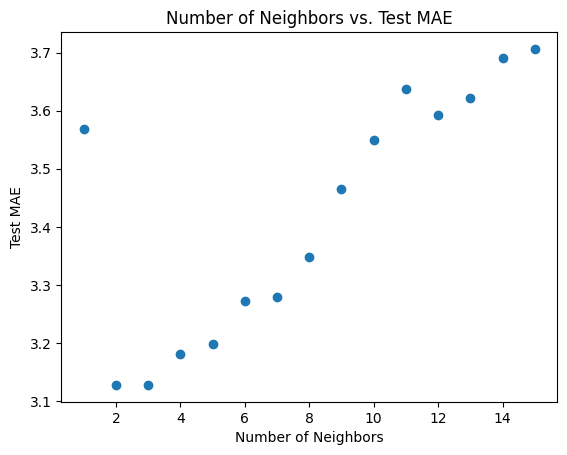

In [7]:
# Learn and graph for different k values
neighbors = [k for k in range(1, 16)]
test_maes = []

for k in neighbors:
    _, _, test_mae, _ = knn_regression(X, y, True, "distance", 0.2, k, 10)
    test_maes.append(test_mae)

plt.clf()
plt.scatter(neighbors, test_maes)
plt.xlabel("Number of Neighbors")
plt.ylabel("Test MAE")
plt.title("Number of Neighbors vs. Test MAE")

plt.show()

#### Discussion
How did the k values affect your results for this dataset? How does that compare to your previous work in this lab?

As the k values increased, the MAE also increased.

This is similar to the trend observed in the observed test accuracy of a model from part 2 - as k increases both the test accuracy and the test mae increase.

At first, I wss suprised to see this. I thought that MAE would decrease or more likely stagnate as k increased. I think that this was my initial impression because I thought that having an increases test accuracy naturally meant that there would be a lesser mean average error. I think that this could be true in the case of other models and regressions, but since we are using K nearest neighbors, I think that as k increases, the bias is increasing majorly. Because the model is forced to make a prediction with more points, points that should have less weight on the classification / output feature are taken into account and so they make the decision boundary more smooth, maybe too smooth even, and cause this bias that makes the model predict in the same wrong direction every time. Or at least, that is how I think about it.

Additionally, I was confused how using weighted distances and normalizing the values didn't help kind of curb that bias a little bit more than I was guessing. To actually check this, I ran the same thing without distance weighting and normalization and the whole graph shifted up by 2+! So, even though numbers around 3 were higher than I was initially expecting given that the data is being used in a way to minimize mae, the normalization and weighting actually did cut down that error by almost half! Which is imressive and a good example of why you would actually do that in a real-world scenario.

## 4. (20%) KNN with nominal and real data

- Use the [lymph dataset](https://axon.cs.byu.edu/data/uci_class/lymph.arff)
- Use a 80/20 split of the data for the training/test set
- This dataset has both continuous and nominal attributes 
- Implement a distance metric which uses Euclidean distance for continuous features and 0/1 distance for nominal. Hints:
    - Write your own distance function (e.g. mydist) and use clf = KNeighborsClassifier(metric=mydist)
    - Change the nominal features in the data set to integer values since KNeighborsClassifier expects numeric features. I used Label_Encoder on the nominal features.
    - Keep a list of which features are nominal which mydist can use to decide which distance measure to use
    - There was an occasional bug in SK version 1.3.0 ("Flags object has no attribute 'c_contiguous'") that went away when I upgraded to the lastest SK version 1.3.1 
- Use your own choice for k and other parameters

In [19]:
# Train/Predict lymph with your own distance metric

# Lymph attributes list
lymph_attributes = ["class",
                    "lymphatics",
                    "block of affere",
                    "bl. of lymph. c",
                    "bl. of lymph. s",
                    "by pass",
                    "extravasates",
                    "regeneration of",
                    "early uptake in",
                    "lym.nodes dimin",
                    "lym.nodes enlar",
                    "changes in lym.",
                    "defect in node",
                    "changes in node",
                    "changes in stru",
                    "special forms",
                    "dislocation of",
                    "exclusion of no",
                    "no. of nodes in"
                    ]

# Read CSV, create df
lymph_df = pd.read_csv("data/lymphography/lymphography.data", header = None, names = lymph_attributes)

# EDA
print("EDA:")
print("\tFirst 5 rows of lymph data set:")
display(lymph_df.head())

print("\n\tLymph Class Distribution:")

print(f"\tData shape: {lymph_df.shape}")

# Split into X and y
X = lymph_df.drop(["class"], axis = 1)
y = lymph_df["class"]

# Convert Nominal features
nominal_attributes = ["lymphatics", 
                      "block of affere",
                      "bl. of lymph. c",
                      "bl. of lymph. s",
                      "by pass",
                      "extravasates",
                      "regeneration of",
                      "early uptake in",
                      "changes in node",
                      "changes in stru",
                      "special forms",
                      "dislocation of",
                      "exclusion of no",
                      ]

for attr in nominal_attributes:
    le = LabelEncoder()
    X[attr] = le.fit_transform(X[attr])

nominal_indices = [X.columns.get_loc(attr) for attr in nominal_attributes]

# Distance function(s)
def mydist(x1, x2):
    """Given two arrays (x1, x2), compute 0/1 distance or Euclidean distance
    depending on nominal or continuous attributes. 
    Returns the distance as a float."""
    dist_nominal = 0
    dist_continuous = 0
    for i in range(len(x1)):
        if i in nominal_indices:
            # implement 0/1 distance
            if x1[i] != x2[i]:
                dist_nominal += 1
        else:
            #implement euclidean distance
            dist_continuous += (x1[i] - x2[i])**2
    return dist_nominal + np.sqrt(dist_continuous)

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size = 0.2, stratify=y)

# Initialize/Fit KNeighbors Classifiera
knn = KNeighborsClassifier(n_neighbors = 5, metric = mydist)
knn.fit(X_train, y_train)

knn_all_continuous = KNeighborsClassifier(n_neighbors = 5)
knn_all_continuous.fit(X_train, y_train)
#Check Accuracies 
train_acc_1 = knn.score(X_train, y_train)
test_acc_1 = knn.score(X_test, y_test)

train_acc_2 = knn_all_continuous.score(X_train, y_train)
test_acc_2 = knn_all_continuous.score(X_train, y_train)

print("\nTrain and Test Accuracies (when using a different distance metric for continuous and nominal values):")
print(f"\n\tTrain Accuracy: {train_acc_1:.4f}")
print(f"\tTest Accuracy: {test_acc_1:.4f}")

print("\nTrain and Test Accuracies (when treating all values as continuous):")
print(f"\n\tTrain Accuracy: {train_acc_2:.4f}")
print(f"\tTest Accuracy: {test_acc_2:.4f}")

EDA:
	First 5 rows of lymph data set:


,class,lymphatics,block of affere,bl. of lymph. c,bl. of lymph. s,by pass,extravasates,regeneration of,early uptake in,lym.nodes dimin,lym.nodes enlar,changes in lym.,defect in node,changes in node,changes in stru,special forms,dislocation of,exclusion of no,no. of nodes in
0,3,4,2,1,1,1,1,1,2,1,2,2,2,4,8,1,1,2,2
1,2,3,2,1,1,2,2,1,2,1,3,3,2,3,4,2,2,2,2
2,3,3,2,2,2,2,2,2,2,1,4,3,3,4,8,3,2,2,7
3,3,3,1,1,1,1,2,1,2,1,3,3,4,4,4,3,1,2,6
4,2,3,1,1,1,1,1,1,1,1,2,2,4,3,5,1,2,2,1



	Lymph Class Distribution:
	Data shape: (148, 19)

Train and Test Accuracies (when using a different distance metric for continuous and nominal values):

	Train Accuracy: 0.8644
	Test Accuracy: 0.6667

Train and Test Accuracies (when treating all values as continuous):

	Train Accuracy: 0.8136
	Test Accuracy: 0.8136


#### Discussion
Explain your distance metric and discuss your results

The distance metric that was used follows the guidelines of this particular aspect of the assignment. I created a list of indicies that corresponded to the nominal values in a given array. Iterating through the indicies of the arrays, checking if the value is nominal, if it was, I compared the two values and made note of every one where there existed a difference. If it was not nomninal, I calculated the square of the differences and added it to a running a total. I then added the number of different nominal points to the sqrt of the sum of differences squared, and returned that value as a float. I compared a model using this distance metric to a model that treated all values as if they were continuous, using the default Euclidean distance to calculate. I then calculated their test and train accuracies, as seen above. 

In the model that uses a custom distance metric depending on the kind of attributes, the train accuracy and test accuracy go back and forth between being greater than one another depending on the random state, which could suggest that the model is incredibly sensitive to the split of the data, which would make sense given that the model is fitting more closely to the specific data points. 

Compared to the model which treats all values the same, using Euclidean distance metrics every time, which always has equal train and test accuracies no matter the random state. The changes in what data is being used to fit the model seem to change the results much less, suggesting a more uniform and consistent prediction across the board. 

I would guess that each of these are used in different situations. The custom distance metric will be more sensitive to the individual data splits and may underfit or overfit depending on the split. Always using Euclidean results in a model that is less sensitive to categorical data and may be less expressive in certain situations. 

## 5. (Optional 15% extra credit) Code up your own KNN Learner 
Below is a scaffold you could use if you want. Requirements for this task:
- Your model should support the methods shown in the example scaffold below
- Use Euclidean distance to decide closest neighbors
- Implement both the classification and regression versions
- Include optional distance weighting for both algorithms
- Run your algorithm on the magic telescope and housing data sets above and discuss and compare your results 

I started this part and didn't finish it! I might come back to it at some point... but probably not haha.

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np

class KNNClassifier(BaseEstimator,ClassifierMixin):
    def __init__(self, columntype=[], weight_type='inverse_distance', n_neighbors = 5): ## add parameters here
        """
        Args:
            columntype for each column tells you if continues[real] or if nominal[categoritcal].
            weight_type: inverse_distance voting or if non distance weighting. Options = ["no_weight","inverse_distance"]
        """
        self.columntype = columntype #Note This won't be needed until part 5
        self.weight_type = weight_type
        self.n_neighbors = n_neighbors

    def fit(self, data, labels):
        """ Fit the data; run the algorithm (for this lab really just saves the data :D)
        Args:
            X (array-like): A 2D numpy array with the training data, excluding targets
            y (array-like): A 2D numpy array with the training targets
        Returns:
            self: this allows this to be chained, e.g. model.fit(X,y).predict(X_test)
        """
        self.X_train = data
        self.y_train = labels
        return self
    
    def predict(self, data):
        """ Predict all classes for a dataset X
        Args:
            X (array-like): A 2D numpy array with the training data, excluding targets
        Returns:
            array, shape (n_samples,)
                Predicted target values per element in X.
        """
        predictions = []

        for test in data:
            distances = []
            for train in self.X_train:
                distance = np.linalg.norm(test-train)
                distances.append(distance)
            #creating dictionary of indicies and distances
            dist_index_list = []
            for i in range(len(distances)):
                dist_index_list.append((distances[i], i))
            dist_index_list.sort()

            nearest = dist_index_list[:self.n_neighbors]

            neighbor_labels = []
            neighbor_distances = []
            for pair in nearest:
                index = pair[1]
                distance = pair[0]
                neighbor_labels.append(self.y_train[index])
                neighbor_distances.append(distance)
            
            label_counts = {}
            if self.weight_type == "no_weight":
                for label in neighbor_labels:
                    if label in label_counts:
                        label_counts[label] +=1
                    else:
                        label_counts[label] = 1
                predicted_label = max(label_counts, key=label_counts.get)
                predictions.append(predicted_label)
            elif self.weight_type == "inverse_distance":
                label_weights = {}
                for label, distance in zip(neighbor_labels, neighbor_distances):
                    weight = 1 / distance
                    if label in label_weights:
                        label_weights[label] += weight
                    else:
                        label_weights[label] = weight
                predicted_label = max(label_weights, key=label_weights.get)
                predictions.append(predicted_label)
            
        return np.array(predictions)


    #Returns the Mean score given input data and labels
    def score(self, X, y):
        """ Return accuracy of model on a given dataset. Must implement own score function.
        Args:
            X (array-like): A 2D numpy array with data, excluding targets
            y (array-like): A 2D numpy array with targets
        Returns:
            score : float
                Mean accuracy of self.predict(X) wrt. y.
        """
        return 0

IndentationError: expected an indented block after 'for' statement on line 45 (2969310913.py, line 51)